**Students:** Ewa Kowalski, Mateo Fuentes
**Section:** A
**Date:** May 3, 2026
**Responsibilities:** We shared the work and both presented.

# CAP3321C Final Project: Miami-Dade Restaurant Inspections

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## Q1. Cleaning

In [2]:
df = pd.read_csv('mdc_restaurant_inspections_2025.csv')
print(df.shape)

(5233, 8)


In [3]:
df.isna().sum()

zip_code 0
inspection_date 0
cuisine 8
score 55
dtype: int64

There are 55 missing scores. We dropped them.

In [4]:
df = df.dropna(subset=['score'])
df['inspection_date'] = pd.to_datetime(df['inspection_date'])
df = df.drop_duplicates(subset='inspection_id')
print(len(df))

5152


Dates are converted and duplicates are removed, leaving 5,152 inspections. (zip_code is still a number.)

In [5]:
tmp = df.copy()

## Q2. Fail rate by ZIP code

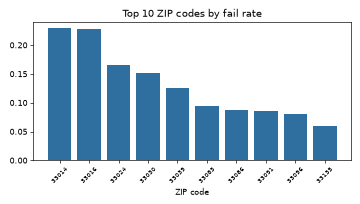

In [6]:
fail_rate = df.assign(fail=df['result'] == 'Fail').groupby('zip_code')['fail'].mean()
top10 = fail_rate.sort_values(ascending=False).head(10)
top10.plot(kind='bar')
plt.show()

## Q3. Scores over time

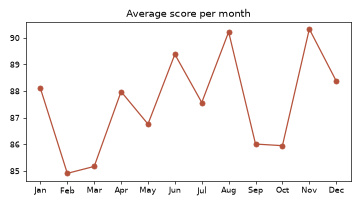

In [7]:
monthly = df.groupby(df['inspection_date'].dt.month)['score'].mean()
monthly.plot(marker='o')
plt.show()

## Q4. Violations by cuisine

In [8]:
per = df.groupby('cuisine')['violations'].mean().sort_values(ascending=False)
per.head(4)

cuisine   violations_per_inspection
Italian   4.16
Peruvian  4.09
Haitian   2.68
Chinese   2.28